<a href="https://colab.research.google.com/github/JerryWan123/Jerry-Wan-s-Assigment-1/blob/main/Jerry_Wan's_CISC_121_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Jerry Wan's CISC 121 - Section 001 – Assignment 2**


## Part 1
### Solve all the 3 problems folloowing the template

1. **Sum of Two Integers** — <https://leetcode.com/problems/sum-of-two-integers>
2. **Convert Date to Binary** — <https://leetcode.com/problems/convert-date-to-binary>
3. **Number of 1 Bits** — <https://leetcode.com/problems/number-of-1-bits>

## Part 2
### Solve 2 of the 3 problems from the followings following the given template

1. **Reverse Integer** — <https://leetcode.com/problems/reverse-integer>
2. **Reverse String** — <https://leetcode.com/problems/reverse-string>
3. **Reverse Pairs** — <https://leetcode.com/problems/reverse-pairs>

### Note: the problems are ordered by difficulty.


1. Your Name: Jerry Wan
2. Section: 001
3. ID: 20526613
4. Github or Colab link of this notebook:
5. Links to Chats: https://chatgpt.com/share/68eb0ad8-4134-8010-885a-cd303c885f6c


#Sum of Two Integers

1. Understanding & Breakdown

This problem requires inputting two integers and finding their sum without using addition or subtraction operators. This problem can be broken down into input, calculation, and output. We only need to focus on the two integers we input and use carry to get the final output. The input integer range should be greater than or equal to -1000 and less than or equal to 1000. I drew the flowchart below.

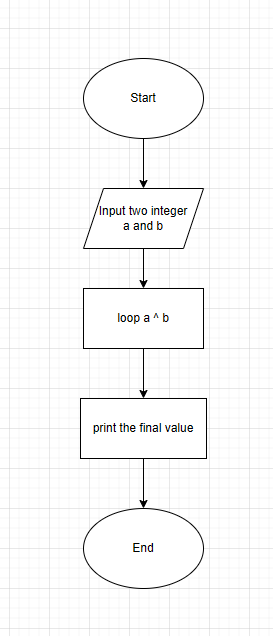

This problem requires limiting the number of integer digits and using some method to determine the sign, sometimes requiring two's complement to restore the negative number. I used a carry method to operate on each bit. I did not use a data set. Compared to the other two problems, both require extensive bitwise operations and loops, and this one requires two's complement masking, otherwise the negative number operation will not be beneficial.

2. Peer Review & Draft Code

I reviewed a solution under the LeetCode and I find a code example by using Python:

https://leetcode.com/problems/sum-of-two-integers/solutions/6402773/in-depth-explanation-easy-clean-solution-beats-100-python-masking-c-java-js/

In his sample code, I learned how to use the carry method, and I can calculate the sum without the carry and calculate the carry to continuously update the number in the variable and finally get the result. I tried to write a draft code myself and referred to his logic:

In [ ]:
def getSum(a, b):
  for _ in range(32):
    sum_without_carry = a ^ b
    carry = (a & b) << 1
    a, b = sum_without_carry, carry
    if b == 0:
      break
  return a

3. Final Correct Code

I have asked ChatGPT and I would like to let it help me check my draft code for basic correctness. But it pointed out a potential error in my code, that is, when performing operations on negative numbers, negative numbers in Python are "infinite bit complements". Without masking, bitwise addition will go astray (or even loop infinitely) on negative numbers.

In [ ]:
# Final working solution:
# [AI Disclaimer: Used ChatGPT with prompt “Please help me check this code” for the code correctness]
def getSum(a, b):
  MASK  = 0xFFFFFFFF   # Fixed to 32 bits
  MAX_INT = 0x7FFFFFFF

    # First constrain a and b to 32-bit two’s complement representation
  a &= MASK
  b &= MASK

    # Bitwise addition: no carry and carry and circular accumulation
  while b != 0:
    sum_ = (a ^ b) & MASK   # Sum without carry
    carry = ((a & b) << 1) & MASK   # Carry
    a, b = sum_, carry

    # Convert the 32-bit two’s complement result back to a Python signed integer
  return a if a <= MAX_INT else ~(a ^ MASK)

Test result:

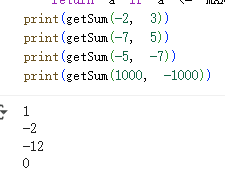

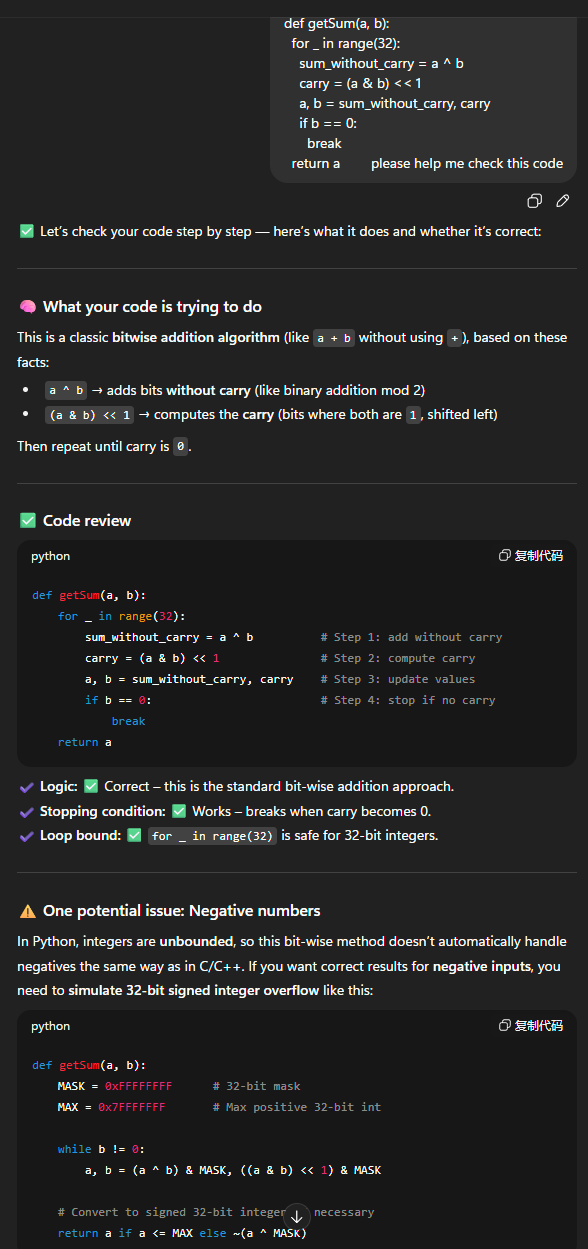

4. Review & Fixes


In [ ]:
# Fix 1: Input range check
# Draft version
def getSum(a, b):
  MASK  = 0xFFFFFFFF
  MAX_INT = 0x7FFFFFFF

# Fixed version
...
assert -1000 <= a <= 1000 and -1000 <= b <= 1000, "Inputs must be in [-1000, 1000]"

In [ ]:
# Fix 2: Parameterizing the bit width
# Draft version
def getSum(a, b):
  MASK  = 0xFFFFFFFF   # Fixed to 32 bits
  MAX_INT = 0x7FFFFFFF

  # First constrain a and b to 32-bit two’s complement representation
  a &= MASK
  b &= MASK

# Fixed version
def getSum(a: int, b: int, bits: int = 16) -> int:
  MASK  = (1 << bits) - 1   # e.g., bits=16 -> 0xFFFF
  MAX_INT = (1 << (bits - 1)) - 1   # e.g., 0x7FFF

  a &= MASK
  b &= MASK

5. Reflection on Your Contribution

In the process of solving this problem, I was able to learn from other people's solutions. This problem can help people shift their existing thinking to a new logic, such as adding two numbers by using carry instead of blindly using operators. I also gained a deeper understanding of Python's operating logic. And AI is very useful for my problem because it can find the problems I have and give me some suggestions for changes.

#Convert Date to Binary

1. Understanding & Breakdown

This problem requires converting a Gregorian calendar date string into binary format and printing it out in year-month-day format. This problem can be broken down into three parts: input, conversion, and output. I'm focusing on converting the input date into binary format, and keeping it within the allowed range. I created the following flowchart.

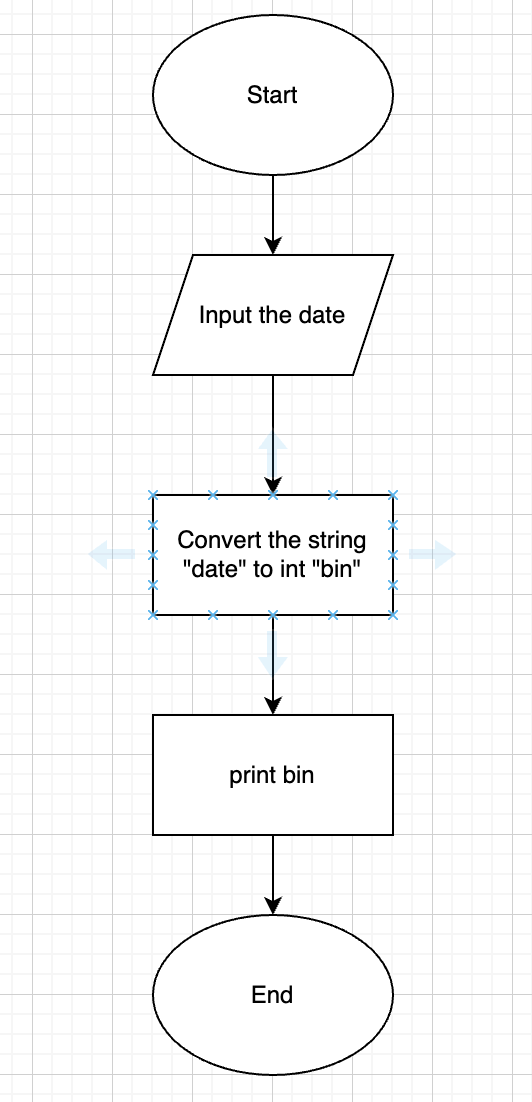

In this problem, I first set up a function to convert decimal to binary, converting the input string to an int before performing the binary conversion. There were some string manipulations, such as the "-" separator between the year, month, and day, and converting text numbers to integers, to achieve the desired output format. In the final code before the improvements, I didn't use any sets. Unlike the other two problems, both involved binary representation of integers, but this one required converting between strings and integers.

2. Peer Review & Draft Code

I reviewed a solution under the LeetCode and I find a code example by using Python:

https://leetcode.com/problems/convert-date-to-binary/solutions/7221141/convert-date-to-binary-easy-optimal-solution-mathematical-approach-c-java-python/

In his code, I learned that he first manually converted the decimal to binary mode, and then converted the date string into binary format through the binary conversion function. I tried to write a draft code myself and referred to his logic:

In [ ]:
def toBin(num: int) -> str:
  if num == 0:
    return "0"
  result = ""
  while num > 0:
    result = str(num % 2) + result
    num //= 2
  return result

def convertDate(date: str) -> str:
  year, month, day = date.split('-')
  y = toBin(int(year))
  m = toBin(int(month))
  d = toBin(int(day))
  return f"{y}-{m}-{d}"

3. Final Correct Code

I have asked ChatGPT and I would like to let it help me check mt draft code. It shows I have completed most fuctions in my code. There is few improvement need to change my code. In summary, I only use AI to check my correctness.

In [4]:
# Final working solution:
def toBin(num: int) -> str:
# Decimal to binary function
  if num == 0:
    return "0"
  result = ""
  while num > 0:
    result = str(num % 2) + result
    num //= 2
  return result

def convertDate(date: str) -> str:
#Convert the date to binary format
  year, month, day = date.split('-')
  y = toBin(int(year))
  m = toBin(int(month))
  d = toBin(int(day))
  return f"{y}-{m}-{d}"


Test Result:

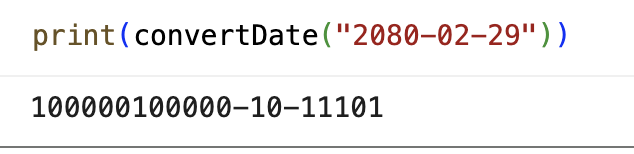

[AI Disclaimer : Used ChatGPT with prompt “Please help me check this code."]

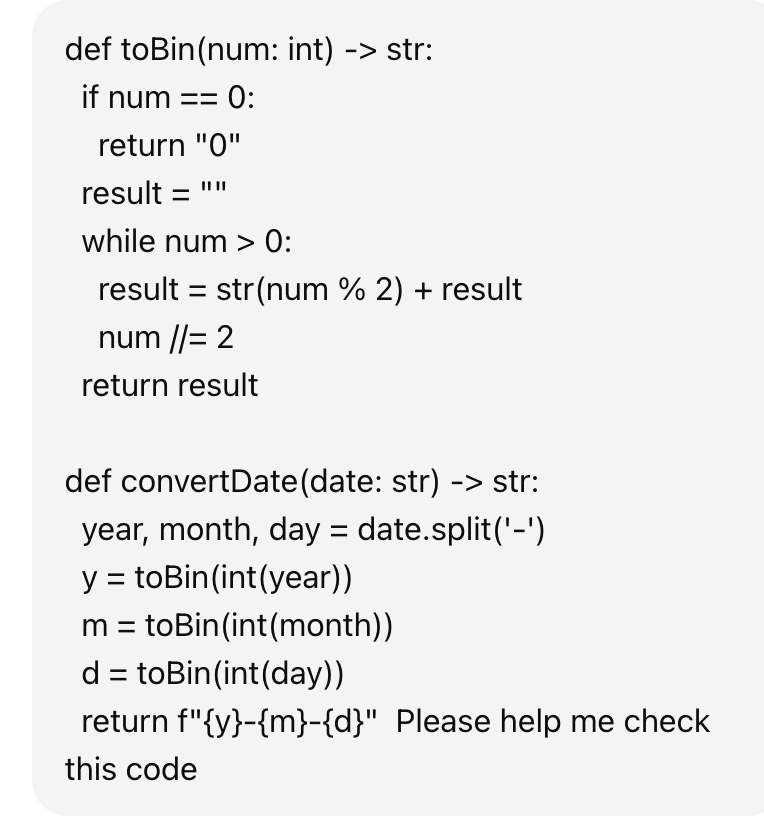

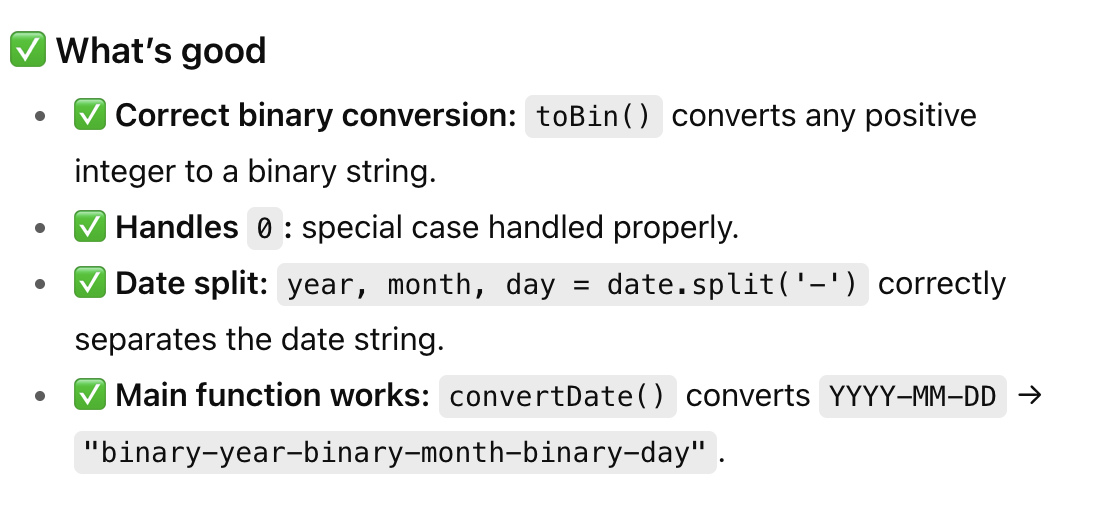

4. Review & Fixes

In [ ]:
# Fix 1: Add input validation
# Draft version
year, month, day = date.split('-')
  y = toBin(int(year))
  m = toBin(int(month))
  d = toBin(int(day))
  return f"{y}-{m}-{d}"

# Fixed version
...
assert 1900 <= year <= 2100, "Year must be between 1900 and 2100"
assert 1 <= month <= 12, "Month must be between 1 and 12"
assert 1 <= day <= 31, "Day must be between 1 and 31"

In [ ]:
# Fix 2: Use list increase efficiency
# Draft version
result = ""
while num > 0:
  result = str(num % 2) + result
  num //= 2
return result

# Fixed version
numList = []
while num > 0:
    numList.append(str(num % 2))
    num //= 2
return "".join(reversed(numList))

5. Reflection on Your Contribution

In this problem, I learned how to convert decimal to binary and used AI to check the correctness of my code. I can't guarantee that my code is correct in all cases, but AI shows that in most cases, my code is fully functional.

#Number of 1 Bits



1. Understanding & Breakdown

This problem requires inputting a positive integer and returning the number of 1s in its binary representation. Similar to the previous problem, this problem also requires converting to binary mode, extracting the digits, and storing the 1s. I created the following flowchart.

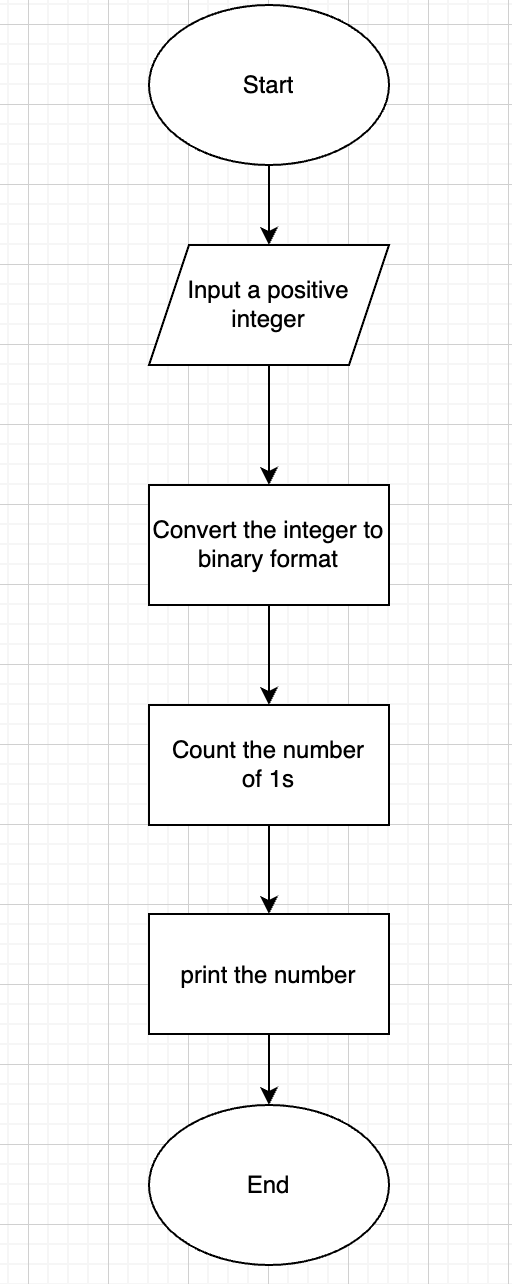

In this problem, the variable data is still int, a positive integer, and an additional variable is set up to store the appropriate result. This problem uses bitwise operations. If the result matches, it is stored in the counting variable, and so on until the last digit is found. I did not use any sets in this problem. Compared to the other two problems, they both use binary and, like the first problem, use bitwise operations. However, they do not involve sign reduction or string processing.

2. Peer Review & Draft Code

I reviewed a solution under the LeetCode and I find a code example by using Python:

https://leetcode.com/problems/number-of-1-bits/solutions/6942378/beats-100-00-2-approach-brute-force-optimal/

In his code, I learned that I could use loops and shifts to check each digit of an integer, and then move the sign right to the next digit until I moved to the last digit. Finally, I could store the number of digits and return its value. I tried to write a draft code myself and referred to his logic:

In [ ]:
def hamming(n: int) -> int:
  count = 0
  while n > 0:
    if n & 1:
      count += 1
    n = n >> 1
  return count

3. Final Correct Code

I asked my AI to check my code for errors. It pointed out that the code wouldn't work if the input was a negative integer or 0. In fact, the question only stated that it only needed positive integers, and the other functions were intact, so there was basically no room for improvement.


In [6]:
# Final working solution:

def hamming(n: int) -> int:
  count = 0
  while n > 0:
    if n & 1:
      count += 1
    n = n >> 1
  return count

Test result:

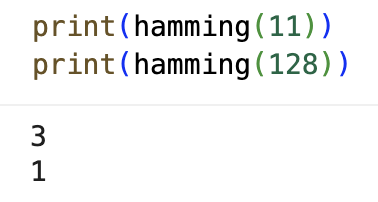

[AI Disclaimer : Used ChatGPT with prompt “Please help me check this code ."]

  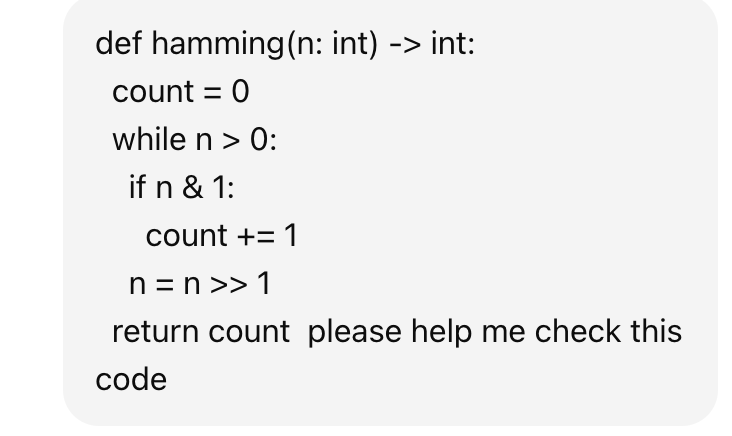

  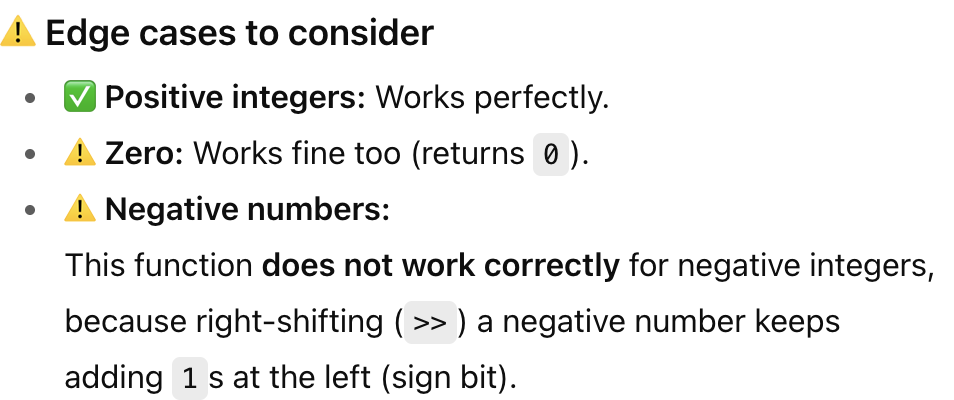

4. Review & Fixes

In [ ]:
# Fix 1: Add some appropriate comments
# Draft version
def hamming(n: int) -> int:
  count = 0
  while n > 0:
    if n & 1:
      count += 1
    n = n >> 1
  return count

# Fixed version
def hamming(n: int) -> int: # n should <= 2^31 - 1 and >= 1
  count = 0
  while n > 0:  # Keep checking until all n are shifted right
    if n & 1:  # heck if the rightmost digit is 1
      count += 1
    n = n >> 1 # Move right one position and continue to check the next position
  return count

In [ ]:
# Fix 2: Bitwise operation optimization
# Draft version
while n > 0:
  if n & 1:
    count += 1
  n = n >> 1
return count

# Fixed version
while n > 0:
  n &= (n - 1)
  count += 1
return count

5. Reflection on Your Contribution

In this problem, the AI helped me consider all the possible scenarios, such as the range of integer values. This allowed me to add more appropriate comments in the improvements below. The AI also suggested some small optimizations that could be used as improvements. So, AI was very useful for this problem.

#Reverse Integer



1. Understanding & Breakdown

This problem requires converting a 32-bit integer into its opposite without changing its sign. If the integer is outside the specified range, it returns 0. This problem requires three parts: input, conversion, and output. I drew the following flowchart.

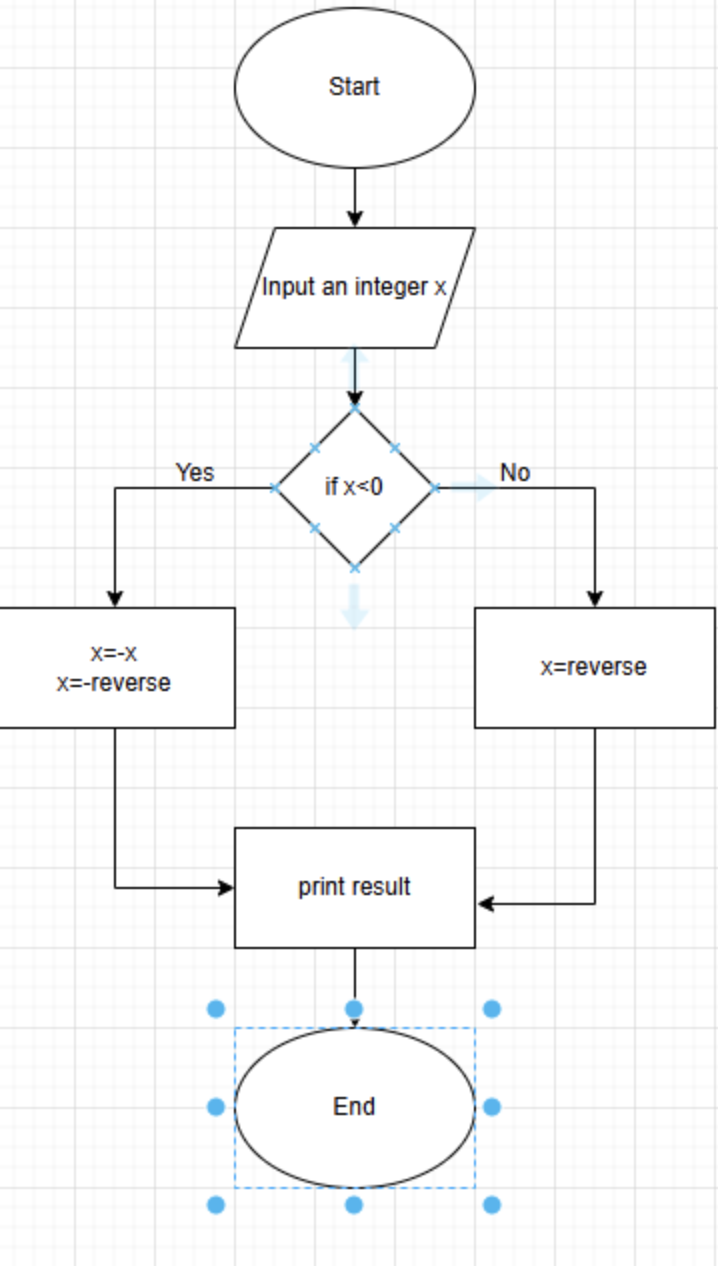

The subproblem and steps to be solved recursively here are to extract the last digit of the current number, reverse the remaining digits, and put each digit in the correct position. Each time, a trailing digit is removed, and the results are concatenated when returned. Head recursion is used because it recursively calls itself before combining the results. Compared to other problems, they share similar logic, such as merging upwards, but the base case in this problem is 0. Compared to the iterative version, the recursive version requires calling a new function at each level. If need to change to tail recursion, it need to carry the current result through additional parameters so that the recursion will not combine the results before returning.

2. Peer Review & Draft Code

I reviewed a solution under the LeetCode and I find a code example by using Python:

https://leetcode.com/problems/reverse-integer/solutions/3497080/c-java-python-javascript-10-lines-of-code-beats-100-0ms/

In his code, I found that he used recursion to change each bit one by one. He also processed the absolute value of the integer, looped around it, and at the end checked whether the result was still within the range. I tried to write a draft code myself and referred to his logic:

In [9]:
def reverseInt(x: int) -> int:
  sign = 1
  if x < 0:
    sign = -1
    x = -x
  result = 0
  while x != 0:
    digit = x % 10
    x = x // 10
    result = result * 10 + digit
  result *= sign
  if result < -(2 ** 31 - 1) or result > 2 ** 31 - 1:
    return 0
  return result

3. Final Correct Code

I used AI to check my program for problems, and it pointed out a small bug. The range of Python int values is slightly different from what I wrote, so I need to change the range. But all other functions are correct.

In [20]:
# Final working solution:
# [AI Disclaimer: Used ChatGPT with prompt “Please help me check this code” for the code correctness]

def reverseInt(x: int) -> int:
  sign = 1
  if x < 0:
    sign = -1
    x = -x
  result = 0
  while x != 0:
    digit = x % 10
    x = x // 10
    result = result * 10 + digit
  result *= sign
  if result < -(2 ** 31) or result > 2 ** 31 - 1: #Change the correct signed 32-bit integer range
    return 0
  return result

Test result:

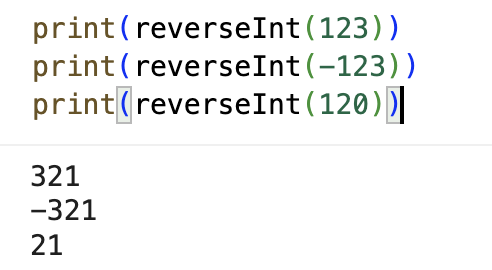

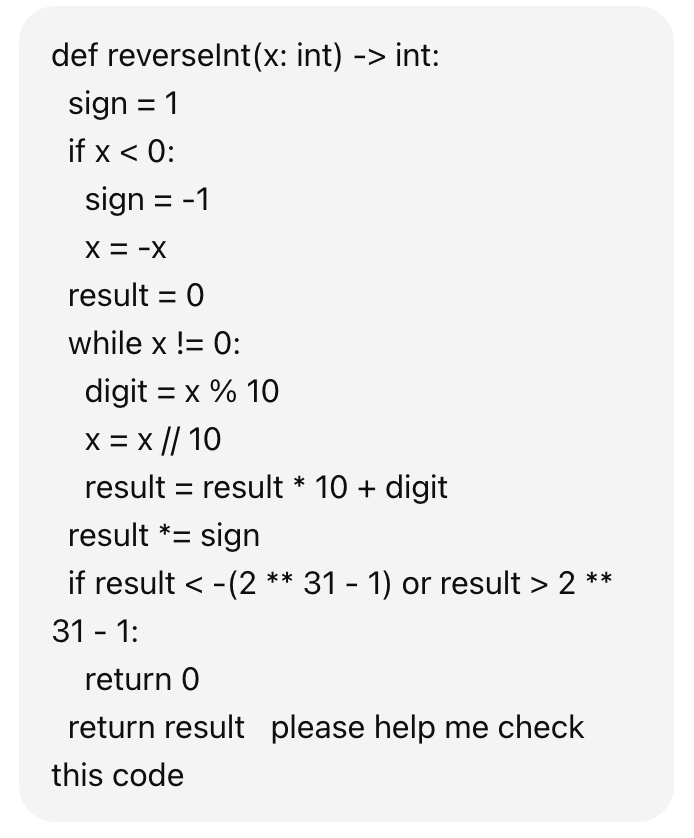

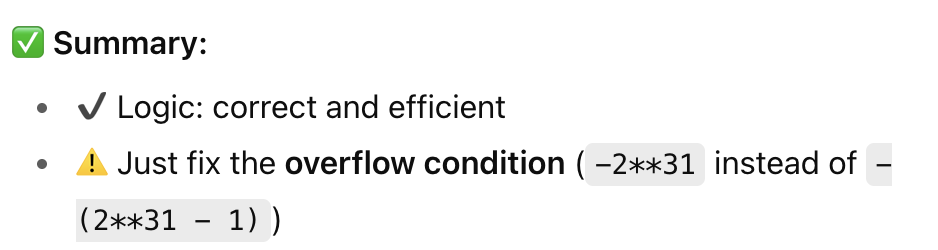

4. Review & Fixes

In [ ]:
# Fix 1: Add input checks
# Draft version
def reverseInt(x: int) -> int:
...

# Fixed version
def reverseInt(x: int) -> int:
  if not isinstance(x, int):
    raise TypeError("Input must be an integer")

In [ ]:
# Fix 2: Set constant variable
# Draft version
def reverseInt(x: int) -> int:
...

# Fixed version
def reverseInt(x: int) -> int:
  MAX_INT = 2 ** 31 - 1
  MIN_INT = -(2 ** 31)

5. Reflection on Your Contribution

The AI discovered a slight error in the range of values in the code I wrote for this problem. I made the corrections promptly based on its prompts, and I also learned the logic used by others when writing this problem.

#Reverse String

1. Understanding & Breakdown

This problem requires reversing an array of strings. The output should be the reversed array, without returning a value. This problem requires three parts: input, reversal, and output. To limit the range of strings, I created the following flowchart.

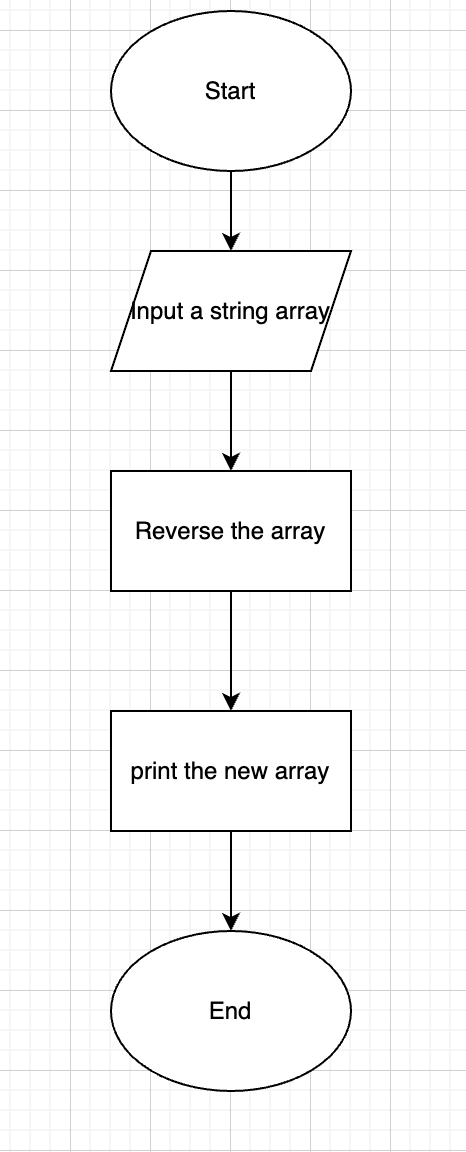

The recursive subproblem for this problem is to reverse a subrange of a string. The steps are to terminate when the left pointer is greater than or equal to the right pointer, swap the characters in the left and right string arrays, and then call the recursive function. However, this problem doesn't do anything upon return because the swap was already done during the recursion. This is a parameterized recursive type, as we use the left and right parameters to record the state. Similar to the other problems, it doesn't require merging results, but unlike them, it doesn't return a value, meaning the modification is in-place. Compared to the iterative version, the recursive version calls the stack at each level. To switch to head recursion, you can recurse to the end before swapping.

2. Peer Review & Draft Code

I reviewed a solution under the LeetCode and I find a code example by using Python:

https://leetcode.com/problems/reverse-string/solutions/6635496/master-the-in-place-swap-trick-to-reverse-any-string-efficiently/

In his code, he sets two variables, swaps the left and right sides, and stops when the left side is greater than the right side. The string is then reversed. I tried to write a draft code myself and referred to his logic:

In [23]:
def reverseStr(s: list[str]) -> None:
  left = 0
  right = len(s) - 1
  while left < right:
    s[left], s[right] = s[right], s[left]
    left += 1
    right -= 1

3. Final Correct Code

I let AI check my code for me. My code is correct and there is no need for improvement.

In [ ]:
# Final working solution:
def reverseStr(s: list[str]) -> None:
  left = 0
  right = len(s) - 1
  while left < right:
    s[left], s[right] = s[right], s[left]
    left += 1
    right -= 1

Test result:

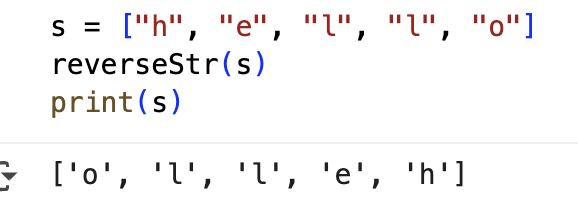

[AI Disclaimer : Used ChatGPT with prompt “Please help me check this code ."]

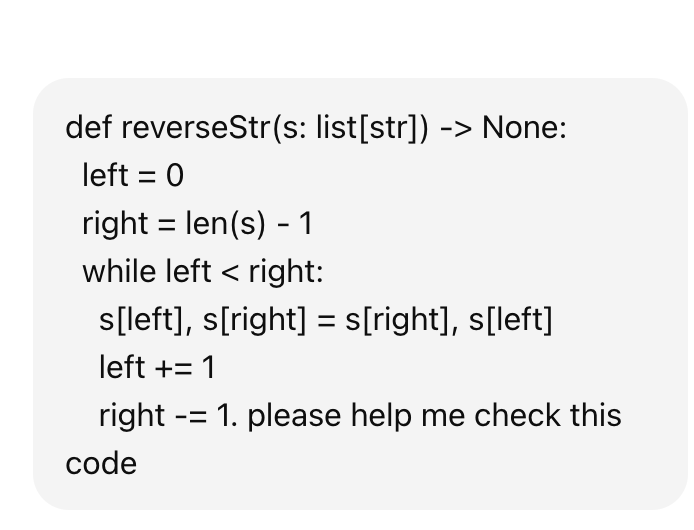

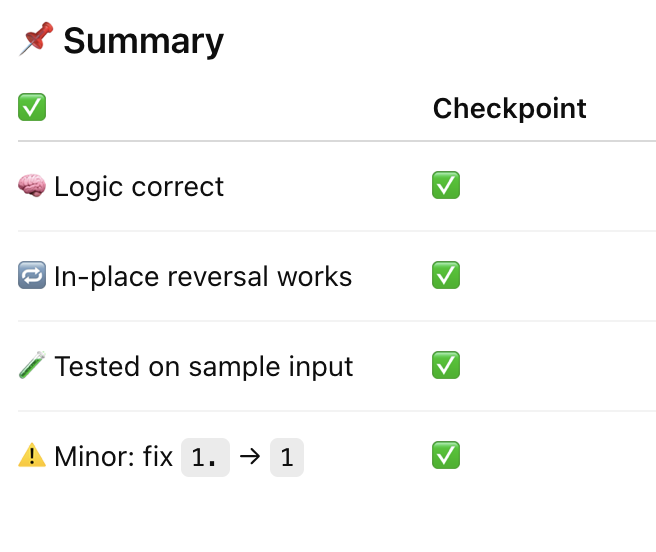

4. Review & Fixes

In [ ]:
# Fix 1: Add input checks
# Draft version
def reverseStr(s: list[str]) -> None:
...

# Fixed version
...
assert isinstance(s, list), "Input must be a list"

In [ ]:
# Fix 2: Add some appropriate comments
# Draft version
def reverseStr(s: list[str]) -> None:
  left = 0
  right = len(s) - 1
  while left < right:
    s[left], s[right] = s[right], s[left]
    left += 1
    right -= 1

# Fixed version
def reverseStr(s: list[str]) -> None:
  left = 0
  right = len(s) - 1
  # Left points to the beginning of the string, right points to the end of the string
  while left < right:
    s[left], s[right] = s[right], s[left]
    # Swap the values ​​of s[left] and s[right]
    left += 1
    right -= 1
    # The left pointer moves one position to the right, and the right pointer moves one position to the left

5. Reflection on Your Contribution

In this problem, AI did not help much, because my code logic was basically correct, I just asked it to check the correctness. And I learned the most convenient way to solve this problem from other people's sample code.